In [3]:
import pandas as pd 
from config import DataSet_path
def read_file(file_path): 
 df =pd.read_csv(file_path)

read_file(DataSet_path)

In [63]:
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [51]:
df.drop(['Ticket','Name','PassengerId'], axis=1 , inplace= True)

In [41]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [46]:
print(df.columns.tolist())

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked']


In [69]:
import config
import importlib

importlib.reload(config)
from config import Cols_drop
df.drop(Cols_drop, axis=1, inplace=True,)

In [60]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [85]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [102]:
dtype=df.dtypes
nunique=df.nunique()
pd.DataFrame({"dtype":dtype,"nunique":nunique }).T

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
dtype,int64,category,category,str,category,category,category,category,category,category,category,category
nunique,891,2,3,891,2,88,7,7,681,248,147,3


In [128]:
df[cols]=df[cols].astype("category")
pd.DataFrame({"dtype":dtype,"nunique":nunique }).T


KeyError: "['Cabin'] not in index"

In [108]:
Cols_type(df)

AttributeError: 'DataFrame' object has no attribute 'dtype'

In [138]:
def Null_info(df):

   pd.DataFrame({"Null":df.isnull().sum() , "ratio":(null/df.shape[0])*100}).T


In [134]:
df.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  889 non-null    int64   
 1   Survived     889 non-null    category
 2   Pclass       889 non-null    category
 3   Name         889 non-null    str     
 4   Sex          889 non-null    category
 5   Age          889 non-null    float64 
 6   SibSp        889 non-null    category
 7   Parch        889 non-null    category
 8   Ticket       889 non-null    category
 9   Fare         889 non-null    category
 10  Embarked     889 non-null    category
dtypes: category(8), float64(1), int64(1), str(1)
memory usage: 72.4 KB


In [133]:
df=df.dropna(subset=["Embarked"])

In [117]:
df=df.drop("Cabin", axis=1)

In [ ]:

df['Age'] = df['Age'].astype(float)
madian=df['Age'].median()
df['Age']=df['Age'].fillna(madian)

In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


ValueError: Columns must be same length as key

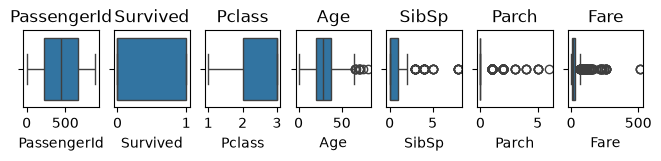

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = len(col_num)
plt.figure(figsize=(8,1))

for i, col in enumerate(col_num):
    plt.subplot(1, 7, i + 1)
    sns.boxplot(df[col], orient='h')
    plt.title(f'{col}')
plt.show()

In [34]:
for col in col_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower_fence, upper_fence)
   # df[col] = df[col].replace(df[df[col] < lower_fence][col].values, lower_fence)
    #df[col] = df[col].replace(df[df[col] > upper_fence][col].values, upper_fence)

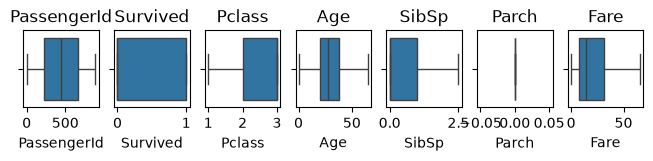

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = len(col_num)
plt.figure(figsize=(8,1))

for i, col in enumerate(col_num):
    plt.subplot(1, 7, i + 1)
    sns.boxplot(df[col], orient='h')
    plt.title(f'{col}')
plt.show()

In [ ]:
df.duplicated().sum()


np.int64(0)

In [39]:
df.drop_duplicates()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1.0,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0,PC 17599,65.6344,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0.0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0.0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0.0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0.0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1.0,0,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0.0,0,111369,30.0000,C148,C


In [40]:
df.duplicated().sum()


np.int64(0)

In [44]:
def remove_duplicates(df, subset_cols=None, keep='first'):
  return (df.drop_duplicates(subset=subset_cols, keep=keep).reset_index(drop=True))


In [46]:
num_col=df.select_dtypes("number").columns

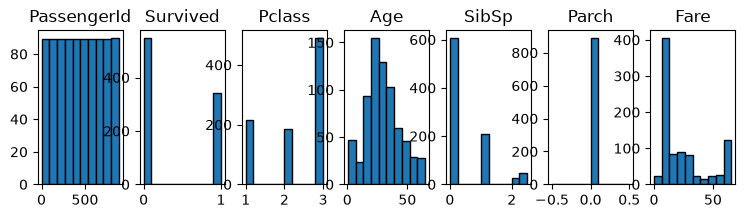

In [51]:
plt.figure(figsize=(9,2))
for i, col in enumerate(num_col):
    plt.subplot(1, 7, i + 1)
    plt.hist(df[col], edgecolor='black')
    plt.title(f'{col}')
plt.show()

C:\Users\zbook g8\AppData\Local\Temp\ipykernel_3332\555882289.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col])


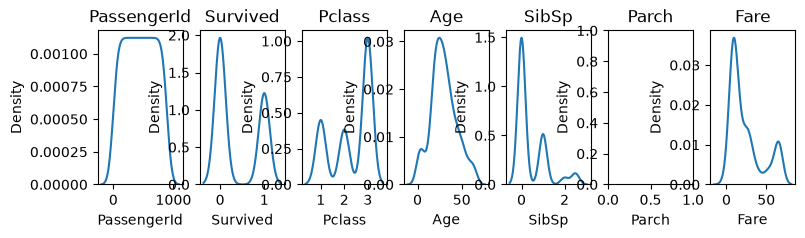

In [53]:
plt.figure(figsize=(9,2))
for i, col in enumerate(num_col):
    plt.subplot(1, 7, i + 1)
    sns.kdeplot(df[col])
    plt.title(f'{col}')
plt.show()

In [87]:
cat_cols=df.select_dtypes("category").columns
plt.figure(figsize=(14,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(df[col], data=df)
    plt.title(f'{col}')
    

<Figure size 1400x400 with 0 Axes>

In [85]:
plt.figure(figsize=(9, 4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    unique = df['Survived'].value_counts()
    count = unique.values
    categories = unique.index
    plt.pie(count , labels=categories,startangle=140, autopct='%1.1d%%')

<Figure size 900x400 with 0 Axes>

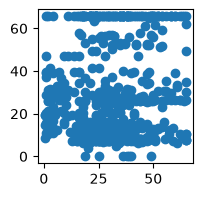

In [88]:
plt.figure(figsize=(2,2))
plt.scatter(df["Age"],df["Fare"])

<Axes: >

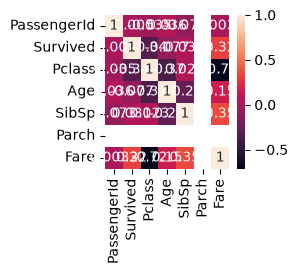

In [92]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(2,2))
sns.heatmap(corr, annot=True)